## Model Development

**Load the engineered dataset and recreate the splits**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

features = pd.read_parquet("../outputs/features/daily_consumption_engineered.parquet")
print("Shape:", features.shape)
print("Date range:", features.index.min(), "->", features.index.max())

train = features.loc["2023-02-01":"2024-06-30"]
val = features.loc["2024-07-01":"2024-08-31"]
test = features.loc["2024-09-01":"2024-10-31"]

y_train = train["consumption_kwh"]
y_val = val["consumption_kwh"]
y_test = test["consumption_kwh"]

print(f"Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}")


Shape: (639, 14)
Date range: 2023-02-01 00:00:00 -> 2024-10-31 00:00:00
Train: 516, Val: 62, Test: 61


**SARIMA order selection via auto_arima**

In [2]:
import pmdarima as pm

sarima_model = pm.auto_arima(
    y_train,
    seasonal=True,
    m=7,                    # weekly seasonality
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore",
    max_p=5, max_q=5, max_P=2, max_Q=2,
)

print(sarima_model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=8445.772, Time=0.65 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=8494.695, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=8465.633, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=8450.029, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=8492.717, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=8444.195, Time=0.36 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=8442.485, Time=0.17 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=8444.173, Time=0.35 sec
 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=8442.015, Time=0.07 sec
 ARIMA(1,1,2)(1,0,0)[7] intercept   : AIC=8444.013, Time=0.12 sec
 ARIMA(1,1,2)(0,0,1)[7] intercept   : AIC=8444.013, Time=0.15 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=8445.915, Time=0.33 sec
 ARIMA(0,1,2)(0,0,0)[7] intercept   : AIC=8440.569, Time=0.05 sec
 ARIMA(0,1,2)(1,0,0)[7] intercept   : AIC=8442.569, Time=0.08 sec
 ARIMA(0,1,2)(0,0,1)[7] intercept

**Check residual autocorrelation at weekly lags to verify the "no seasonality" call**

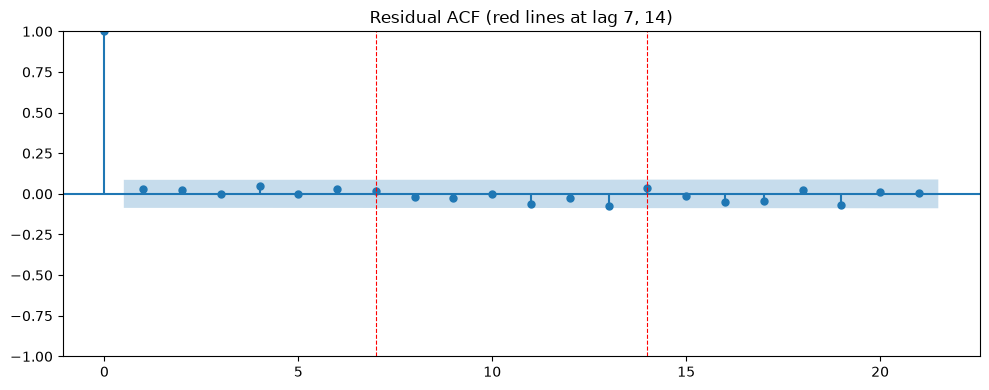

      lb_stat  lb_pvalue
7    2.568700   0.921836
14   9.485072   0.798779
21  14.843275   0.830733


In [3]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = sarima_model.resid()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(residuals, lags=21, ax=ax)
ax.axvline(7, color="red", linestyle="--", linewidth=0.8)
ax.axvline(14, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Residual ACF (red lines at lag 7, 14)")
plt.tight_layout()
plt.show()

# Formal test for residual autocorrelation specifically at weekly lags
lb_test = acorr_ljungbox(residuals, lags=[7, 14, 21], return_df=True)
print(lb_test)


**Forecast the validation period and evaluate**

SARIMA validation — MAE: 1123.5, RMSE: 1388.8, MAPE: 6.83%


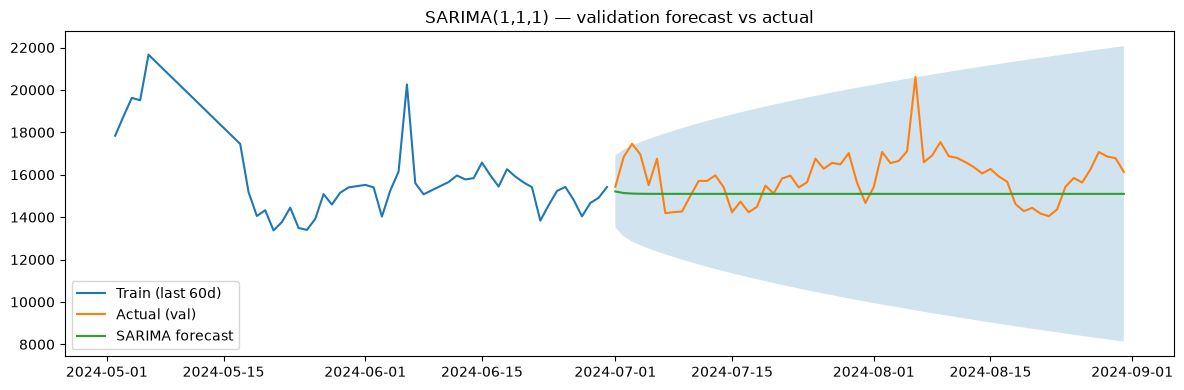

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

n_periods = len(y_val)
forecast, conf_int = sarima_model.predict(n_periods=n_periods, return_conf_int=True)
forecast = pd.Series(forecast, index=y_val.index)

mae = mean_absolute_error(y_val, forecast)
rmse = np.sqrt(mean_squared_error(y_val, forecast))
mape = np.mean(np.abs((y_val - forecast) / y_val)) * 100

print(f"SARIMA validation — MAE: {mae:.1f}, RMSE: {rmse:.1f}, MAPE: {mape:.2f}%")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_train.index[-60:], y_train.values[-60:], label="Train (last 60d)")
ax.plot(y_val.index, y_val.values, label="Actual (val)")
ax.plot(forecast.index, forecast.values, label="SARIMA forecast")
ax.fill_between(forecast.index, conf_int[:, 0], conf_int[:, 1], alpha=0.2)
ax.legend()
ax.set_title("SARIMA(1,1,1) — validation forecast vs actual")
plt.tight_layout()
plt.show()


**Scale the series and build the windowing function**

In [5]:
from sklearn.preprocessing import MinMaxScaler

LOOKBACK = 30
HORIZON = 30

scaler = MinMaxScaler()
scaler.fit(y_train.values.reshape(-1, 1))

full_series = features["consumption_kwh"]
scaled_series = pd.Series(scaler.transform(full_series.values.reshape(-1, 1)).flatten(), index=full_series.index)

def build_windows(series, lookback, horizon, target_start, target_end):
    """Build (X, y) windows where the target's FULL horizon falls within [target_start, target_end]."""
    X, y, origin_dates = [], [], []
    values = series.values
    dates = series.index
    for i in range(lookback, len(series) - horizon + 1):
        target_dates = dates[i:i + horizon]
        if target_dates[0] >= pd.Timestamp(target_start) and target_dates[-1] <= pd.Timestamp(target_end):
            X.append(values[i - lookback:i])
            y.append(values[i:i + horizon])
            origin_dates.append(dates[i])
    return np.array(X), np.array(y), origin_dates

X_train, y_train_seq, _ = build_windows(scaled_series, LOOKBACK, HORIZON, "2023-02-01", "2024-06-30")
X_val, y_val_seq, val_origin_dates = build_windows(scaled_series, LOOKBACK, HORIZON, "2024-07-01", "2024-08-31")

print("X_train:", X_train.shape, "y_train_seq:", y_train_seq.shape)
print("X_val:", X_val.shape, "y_val_seq:", y_val_seq.shape)


X_train: (457, 30) y_train_seq: (457, 30)
X_val: (33, 30) y_val_seq: (33, 30)


**Build and train a baseline LSTM**

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(SEED)

X_train_r = X_train.reshape(-1, LOOKBACK, 1)
X_val_r = X_val.reshape(-1, LOOKBACK, 1)

model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, 1)),
    layers.LSTM(64),
    layers.Dropout(0.2),
    layers.Dense(HORIZON),
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train_r, y_train_seq,
    validation_data=(X_val_r, y_val_seq),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1,
)

print(f"\nStopped at epoch {len(history.history['loss'])}")
print(f"Best val_loss: {min(history.history['val_loss']):.5f}")


Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0809 - mae: 0.2274 - val_loss: 0.0203 - val_mae: 0.1086
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0301 - mae: 0.1326 - val_loss: 0.0189 - val_mae: 0.1052
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0267 - mae: 0.1245 - val_loss: 0.0182 - val_mae: 0.1029
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0254 - mae: 0.1214 - val_loss: 0.0178 - val_mae: 0.1017
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0251 - mae: 0.1202 - val_loss: 0.0179 - val_mae: 0.1019
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0242 - mae: 0.1181 - val_loss: 0.0178 - val_mae: 0.1015
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0241 - mae: 0.1189 - val_loss: 0.0176 - val_mae: 0.1009
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0236 - mae: 0.1172 - val_loss: 0.0176 - val_mae: 0.1009
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.02

**Evaluate in real units (kWh), not scaled space**

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
LSTM validation (all 33 x 30-day windows) — MAE: 929.2, RMSE: 1228.2, MAPE: 5.72%


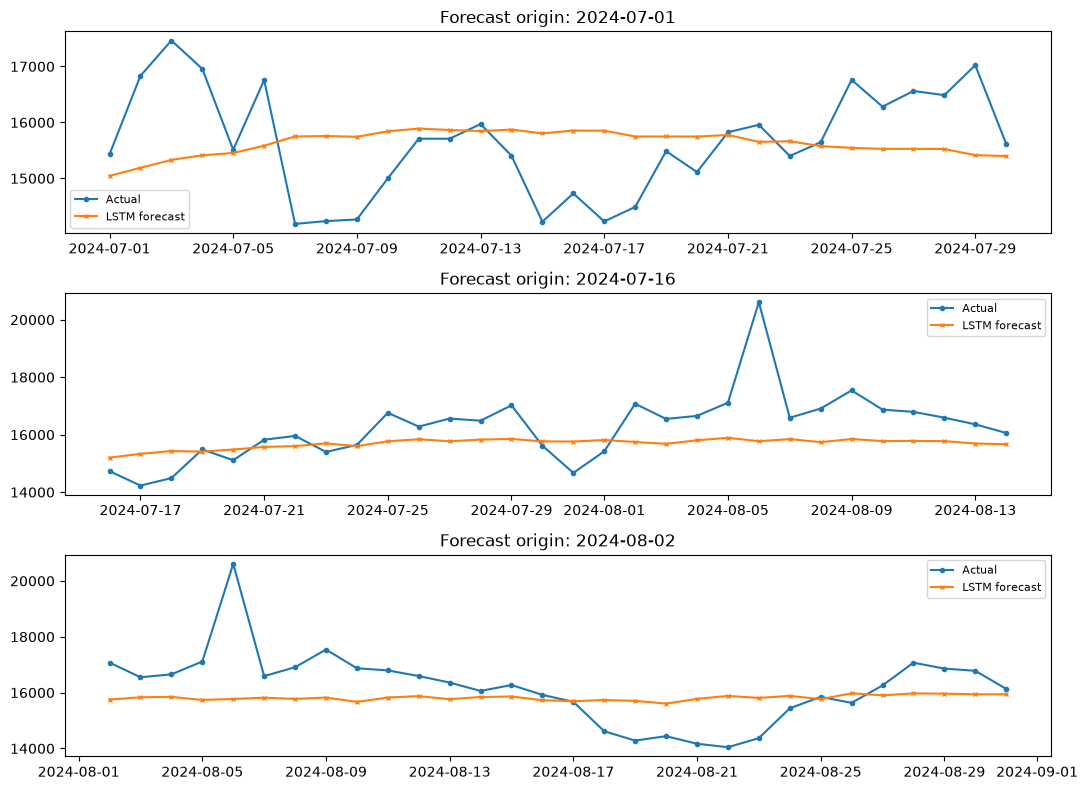

In [7]:
pred_val_scaled = model.predict(X_val_r)

pred_val = scaler.inverse_transform(pred_val_scaled)
actual_val = scaler.inverse_transform(y_val_seq)

mae = mean_absolute_error(actual_val.flatten(), pred_val.flatten())
rmse = np.sqrt(mean_squared_error(actual_val.flatten(), pred_val.flatten()))
mape = np.mean(np.abs((actual_val - pred_val) / actual_val)) * 100

print(f"LSTM validation (all 33 x 30-day windows) — MAE: {mae:.1f}, RMSE: {rmse:.1f}, MAPE: {mape:.2f}%")

# Plot a few example forecast windows
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=False)
for ax, idx in zip(axes, [0, 15, 32]):
    origin = val_origin_dates[idx]
    forecast_dates = pd.date_range(origin, periods=HORIZON, freq="D")
    ax.plot(forecast_dates, actual_val[idx], label="Actual", marker="o", markersize=3)
    ax.plot(forecast_dates, pred_val[idx], label="LSTM forecast", marker="x", markersize=3)
    ax.set_title(f"Forecast origin: {origin.date()}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Rebuild windows with calendar features included (past + known future)**

In [12]:
dow_sin = np.sin(2 * np.pi * features["day_of_week"] / 7)
dow_cos = np.cos(2 * np.pi * features["day_of_week"] / 7)
is_weekend = features["is_weekend"]

calendar = pd.DataFrame({"dow_sin": dow_sin, "dow_cos": dow_cos, "is_weekend": is_weekend}, index=features.index)

def build_windows_v2(series, calendar_df, lookback, horizon, target_start, target_end):
    X_cons, X_cal_past, X_cal_future, y, origins = [], [], [], [], []
    values = series.values
    cal_values = calendar_df.values
    dates = series.index
    for i in range(lookback, len(series) - horizon + 1):
        target_dates = dates[i:i + horizon]
        if target_dates[0] >= pd.Timestamp(target_start) and target_dates[-1] <= pd.Timestamp(target_end):
            X_cons.append(values[i - lookback:i])
            X_cal_past.append(cal_values[i - lookback:i])
            X_cal_future.append(cal_values[i:i + horizon])
            y.append(values[i:i + horizon])
            origins.append(dates[i])
    return np.array(X_cons), np.array(X_cal_past), np.array(X_cal_future), np.array(y), origins

Xc_train, Xcalp_train, Xcalf_train, y_train_seq2, _ = build_windows_v2(scaled_series, calendar, LOOKBACK, HORIZON, "2023-02-01", "2024-06-30")
Xc_val, Xcalp_val, Xcalf_val, y_val_seq2, val_origin_dates2 = build_windows_v2(scaled_series, calendar, LOOKBACK, HORIZON, "2024-07-01", "2024-08-31")

print("Xc_train:", Xc_train.shape, "Xcalp_train:", Xcalp_train.shape, "Xcalf_train:", Xcalf_train.shape)
print("Xc_val:", Xc_val.shape, "Xcalf_val:", Xcalf_val.shape)


Xc_train: (457, 30) Xcalp_train: (457, 30, 3) Xcalf_train: (457, 30, 3)
Xc_val: (33, 30) Xcalf_val: (33, 30, 3)


**Build the multi-input LSTM (encoder over past consumption+calendar, plus known future calendar)**

In [14]:
past_cons_input = layers.Input(shape=(LOOKBACK, 1), name="past_consumption")
past_cal_input = layers.Input(shape=(LOOKBACK, 3), name="past_calendar")
future_cal_input = layers.Input(shape=(HORIZON, 3), name="future_calendar")

encoder_in = layers.Concatenate(axis=-1)([past_cons_input, past_cal_input])
encoder_out = layers.LSTM(64)(encoder_in)

future_flat = layers.Flatten()(future_cal_input)
future_dense = layers.Dense(32, activation="relu")(future_flat)

merged = layers.Concatenate()([encoder_out, future_dense])
merged = layers.Dense(64, activation="relu")(merged)
merged = layers.Dropout(0.2)(merged)
output = layers.Dense(HORIZON)(merged)

model2 = keras.Model(inputs=[past_cons_input, past_cal_input, future_cal_input], outputs=output)
model2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

Xc_train_r = Xc_train.reshape(-1, LOOKBACK, 1)
Xc_val_r = Xc_val.reshape(-1, LOOKBACK, 1)

early_stop2 = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history2 = model2.fit(
    [Xc_train_r, Xcalp_train, Xcalf_train], y_train_seq2,
    validation_data=([Xc_val_r, Xcalp_val, Xcalf_val], y_val_seq2),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop2],
    verbose=1,
)

print(f"\nStopped at epoch {len(history2.history['loss'])}")
print(f"Best val_loss: {min(history2.history['val_loss']):.5f}")


Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1101 - mae: 0.2606 - val_loss: 0.0475 - val_mae: 0.1717
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0425 - mae: 0.1596 - val_loss: 0.0236 - val_mae: 0.1200
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0320 - mae: 0.1383 - val_loss: 0.0202 - val_mae: 0.1092
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0294 - mae: 0.1322 - val_loss: 0.0186 - val_mae: 0.1044
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0293 - mae: 0.1318 - val_loss: 0.0188 - val_mae: 0.1052
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0286 - mae: 0.1287 - val_loss: 0.0193 - val_mae: 0.1070
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0268 - mae: 0.1253 - val_loss: 0.0194 - val_mae: 0.1072
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0261 - mae: 0.1236 - val_loss: 0.0180 - val_mae: 0.1025
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.02

**Evaluate in real units and check the plots again**

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
LSTM+calendar validation — MAE: 913.8, RMSE: 1220.5, MAPE: 5.73%


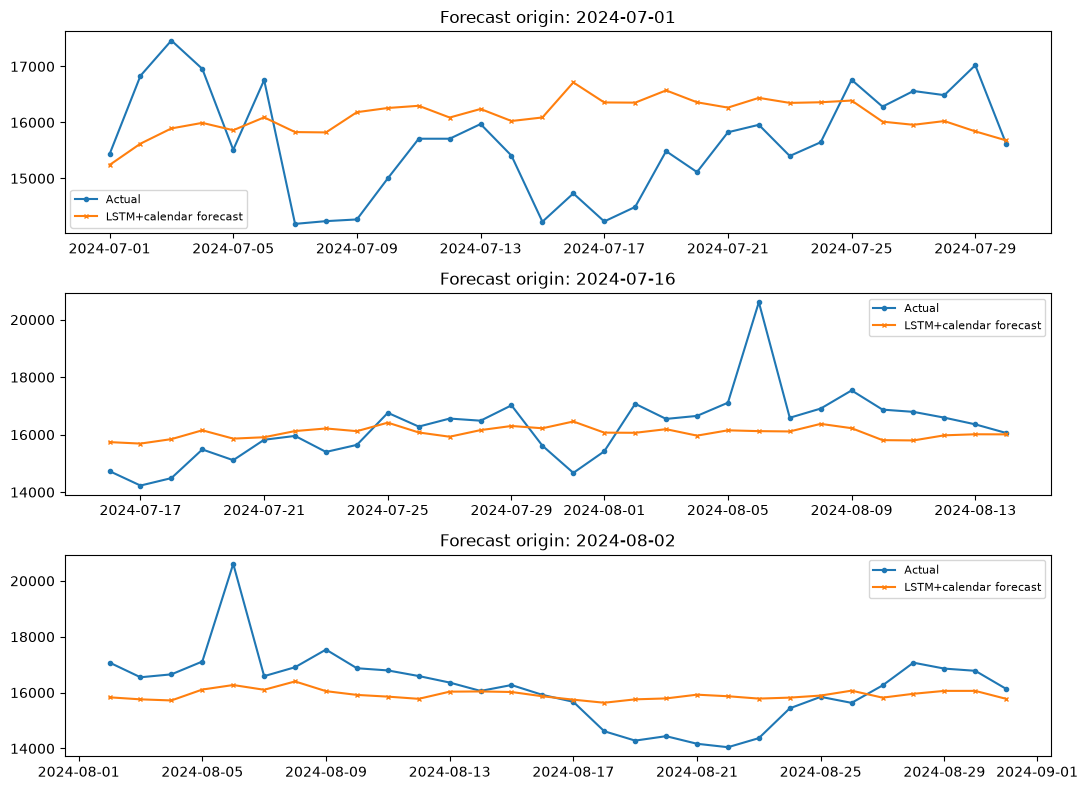

In [15]:
pred_val2_scaled = model2.predict([Xc_val_r, Xcalp_val, Xcalf_val])
pred_val2 = scaler.inverse_transform(pred_val2_scaled)
actual_val2 = scaler.inverse_transform(y_val_seq2)

mae2 = mean_absolute_error(actual_val2.flatten(), pred_val2.flatten())
rmse2 = np.sqrt(mean_squared_error(actual_val2.flatten(), pred_val2.flatten()))
mape2 = np.mean(np.abs((actual_val2 - pred_val2) / actual_val2)) * 100

print(f"LSTM+calendar validation — MAE: {mae2:.1f}, RMSE: {rmse2:.1f}, MAPE: {mape2:.2f}%")

fig, axes = plt.subplots(3, 1, figsize=(11, 8))
for ax, idx in zip(axes, [0, 15, 32]):
    origin = val_origin_dates2[idx]
    forecast_dates = pd.date_range(origin, periods=HORIZON, freq="D")
    ax.plot(forecast_dates, actual_val2[idx], label="Actual", marker="o", markersize=3)
    ax.plot(forecast_dates, pred_val2[idx], label="LSTM+calendar forecast", marker="x", markersize=3)
    ax.set_title(f"Forecast origin: {origin.date()}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Build a long-format table for direct multi-horizon XGBoost forecasting**

In [16]:
LAG_ROLLING_COLS = ["lag_1", "lag_7", "lag_14", "lag_30", "rolling_mean_7", "rolling_std_7", "rolling_mean_30"]
TARGET_CALENDAR_COLS = ["day_of_week", "is_weekend", "month", "is_sl_public_holiday", "is_tariff_revision_day", "days_since_tariff_revision"]

def build_long_format(feat_df, horizon, target_start, target_end):
    rows = []
    valid_origins = feat_df.dropna(subset=LAG_ROLLING_COLS).index
    for origin in valid_origins:
        for h in range(1, horizon + 1):
            target_date = origin + pd.Timedelta(days=h)
            if target_date not in feat_df.index:
                continue
            if not (pd.Timestamp(target_start) <= target_date <= pd.Timestamp(target_end)):
                continue
            row = {col: feat_df.loc[origin, col] for col in LAG_ROLLING_COLS}
            row["horizon_step"] = h
            for col in TARGET_CALENDAR_COLS:
                row[f"target_{col}"] = feat_df.loc[target_date, col]
            row["target"] = feat_df.loc[target_date, "consumption_kwh"]
            row["origin_date"] = origin
            row["target_date"] = target_date
            rows.append(row)
    return pd.DataFrame(rows)

xgb_train_long = build_long_format(features, HORIZON, "2023-02-01", "2024-06-30")
xgb_val_long = build_long_format(features, HORIZON, "2024-07-01", "2024-08-31")

print("Train rows:", xgb_train_long.shape)
print("Val rows:", xgb_val_long.shape)
xgb_train_long.head()


Train rows: (14115, 17)
Val rows: (1860, 17)


,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_30,horizon_step,target_day_of_week,target_is_weekend,target_month,target_is_sl_public_holiday,target_is_tariff_revision_day,target_days_since_tariff_revision,target,origin_date,target_date
0,14019.536662,12651.465236,14052.341373,12387.477138,13528.16331,448.140864,13583.738858,1,5,1,3,0,0,17,13833.023982,2023-03-03,2023-03-04
1,14019.536662,12651.465236,14052.341373,12387.477138,13528.16331,448.140864,13583.738858,2,6,1,3,0,0,18,13718.829225,2023-03-03,2023-03-05
2,14019.536662,12651.465236,14052.341373,12387.477138,13528.16331,448.140864,13583.738858,3,0,0,3,1,0,19,13237.167006,2023-03-03,2023-03-06
3,14019.536662,12651.465236,14052.341373,12387.477138,13528.16331,448.140864,13583.738858,4,1,0,3,0,0,20,13284.929534,2023-03-03,2023-03-07
4,14019.536662,12651.465236,14052.341373,12387.477138,13528.16331,448.140864,13583.738858,5,2,0,3,0,0,21,13519.746249,2023-03-03,2023-03-08


**Train a baseline XGBoost on the long-format table**

In [17]:
import xgboost as xgb

FEATURE_COLS = LAG_ROLLING_COLS + ["horizon_step"] + [f"target_{c}" for c in TARGET_CALENDAR_COLS]

X_train_xgb = xgb_train_long[FEATURE_COLS]
y_train_xgb = xgb_train_long["target"]
X_val_xgb = xgb_val_long[FEATURE_COLS]
y_val_xgb = xgb_val_long["target"]

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    early_stopping_rounds=20,
    eval_metric="mae",
)

xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False,
)

print("Best iteration:", xgb_model.best_iteration)

pred_val_xgb = xgb_model.predict(X_val_xgb)
mae = mean_absolute_error(y_val_xgb, pred_val_xgb)
rmse = np.sqrt(mean_squared_error(y_val_xgb, pred_val_xgb))
mape = np.mean(np.abs((y_val_xgb - pred_val_xgb) / y_val_xgb)) * 100

print(f"XGBoost validation — MAE: {mae:.1f}, RMSE: {rmse:.1f}, MAPE: {mape:.2f}%")


Best iteration: 28
XGBoost validation — MAE: 851.4, RMSE: 1119.4, MAPE: 5.39%


**Reconstruct forecast windows and plot, plus feature importance**

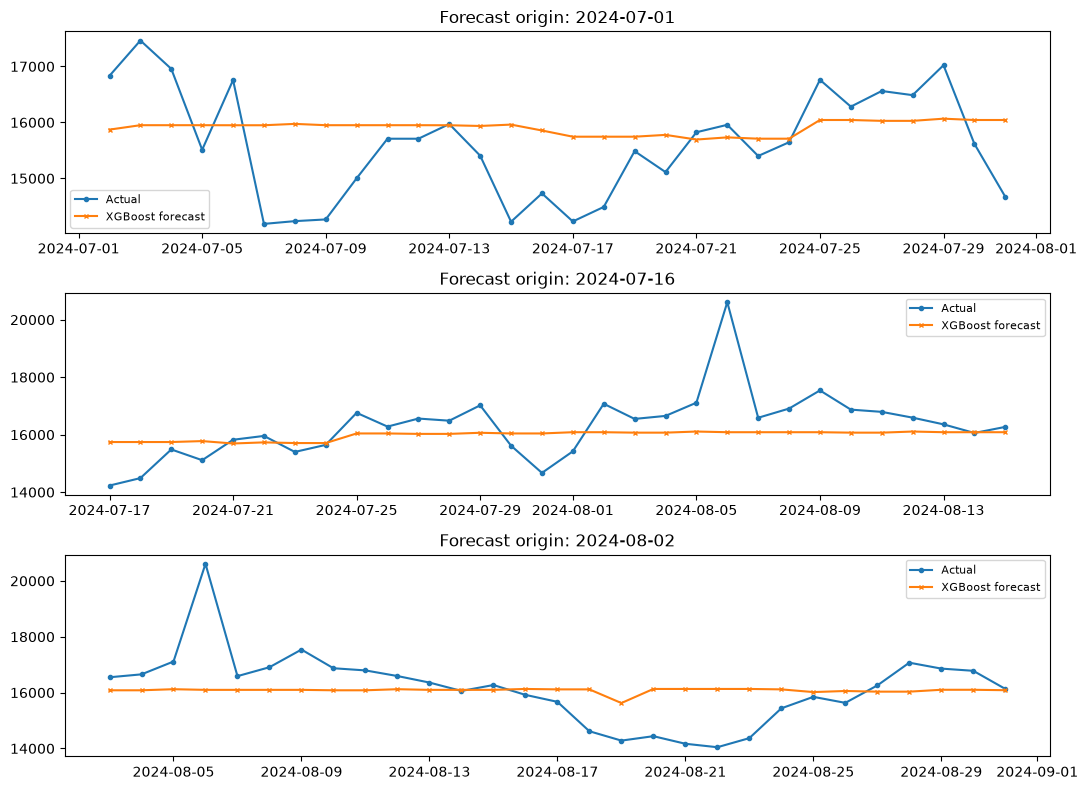

target_month                         0.333393
rolling_mean_30                      0.131920
rolling_mean_7                       0.118749
lag_14                               0.100231
lag_30                               0.076954
target_days_since_tariff_revision    0.051036
target_is_sl_public_holiday          0.049341
rolling_std_7                        0.041285
lag_1                                0.035389
lag_7                                0.018451
horizon_step                         0.013887
target_is_weekend                    0.013790
target_day_of_week                   0.012154
target_is_tariff_revision_day        0.003422
dtype: float32


In [18]:
xgb_val_long = xgb_val_long.copy()
xgb_val_long["prediction"] = pred_val_xgb

# Pick the same 3 example origins used for LSTM, if present in this table
example_origins = [pd.Timestamp("2024-07-01"), pd.Timestamp("2024-07-16"), pd.Timestamp("2024-08-02")]

fig, axes = plt.subplots(3, 1, figsize=(11, 8))
for ax, origin in zip(axes, example_origins):
    window = xgb_val_long[xgb_val_long["origin_date"] == origin].sort_values("horizon_step")
    ax.plot(window["target_date"], window["target"], label="Actual", marker="o", markersize=3)
    ax.plot(window["target_date"], window["prediction"], label="XGBoost forecast", marker="x", markersize=3)
    ax.set_title(f"Forecast origin: {origin.date()}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(importances)


**Optuna tuning for SARIMA**

In [31]:
import optuna
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

def sarima_objective(trial):
    p = trial.suggest_int("p", 0, 3)
    q = trial.suggest_int("q", 0, 3)
    P = trial.suggest_int("P", 0, 2)
    D = trial.suggest_int("D", 0, 1)
    Q = trial.suggest_int("Q", 0, 2)
    try:
        model = SARIMAX(y_train, order=(p, 1, q), seasonal_order=(P, D, Q, 7),
                         enforce_stationarity=False, enforce_invertibility=False)
        fit = model.fit(disp=False)
        forecast = fit.forecast(steps=len(y_val))
        return mean_absolute_error(y_val, forecast)
    except Exception:
        return float("inf")

sarima_study = optuna.create_study(direction="minimize")
sarima_study.optimize(sarima_objective, n_trials=30, show_progress_bar=True)

print("Best SARIMA params:", sarima_study.best_params)
print("Best SARIMA val MAE:", sarima_study.best_value)

  0%|          | 0/30 [00:00<?, ?it/s]

Best SARIMA params: {'p': 2, 'q': 0, 'P': 1, 'D': 1, 'Q': 1}
Best SARIMA val MAE: 871.7515757396641


**Refit the best SARIMA and inspect the forecast**

Tuned SARIMA validation — MAE: 871.8, RMSE: 1150.5, MAPE: 5.47%


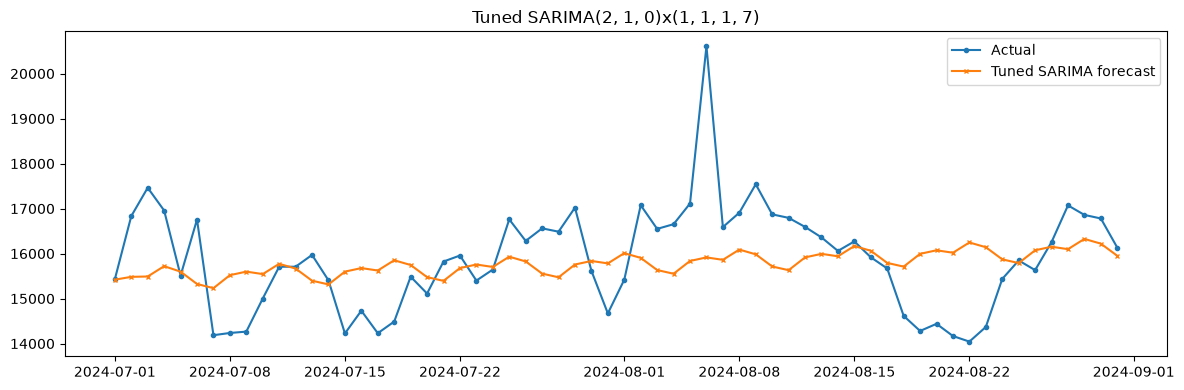

In [32]:
best = sarima_study.best_params
final_sarima = SARIMAX(y_train, order=(best["p"], 1, best["q"]),
                        seasonal_order=(best["P"], best["D"], best["Q"], 7),
                        enforce_stationarity=False, enforce_invertibility=False)
final_sarima_fit = final_sarima.fit(disp=False)

forecast_tuned = final_sarima_fit.forecast(steps=len(y_val))

mae = mean_absolute_error(y_val, forecast_tuned)
rmse = np.sqrt(mean_squared_error(y_val, forecast_tuned))
mape = np.mean(np.abs((y_val - forecast_tuned) / y_val)) * 100
print(f"Tuned SARIMA validation — MAE: {mae:.1f}, RMSE: {rmse:.1f}, MAPE: {mape:.2f}%")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_val.index, y_val.values, label="Actual", marker="o", markersize=3)
ax.plot(y_val.index, forecast_tuned.values, label="Tuned SARIMA forecast", marker="x", markersize=3)
ax.legend()
ax.set_title(f"Tuned SARIMA{(best['p'],1,best['q'])}x{(best['P'],best['D'],best['Q'],7)}")
plt.tight_layout()
plt.show()


**Optuna tuning for XGBoost**

In [33]:
def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
    }
    model = xgb.XGBRegressor(**params, random_state=SEED, early_stopping_rounds=20, eval_metric="mae")
    model.fit(X_train_xgb, y_train_xgb, eval_set=[(X_val_xgb, y_val_xgb)], verbose=False)
    pred = model.predict(X_val_xgb)
    return mean_absolute_error(y_val_xgb, pred)

xgb_study = optuna.create_study(direction="minimize")
xgb_study.optimize(xgb_objective, n_trials=20, show_progress_bar=True)

print("Best XGBoost params:", xgb_study.best_params)
print("Best XGBoost val MAE:", xgb_study.best_value)


  0%|          | 0/20 [00:00<?, ?it/s]

Best XGBoost params: {'n_estimators': 507, 'max_depth': 3, 'learning_rate': 0.1256811598167977, 'subsample': 0.7553471381943498, 'colsample_bytree': 0.8847936528260443, 'reg_alpha': 0.6523685294345549, 'reg_lambda': 0.7763628833688613}
Best XGBoost val MAE: 820.0739521024078


**Finalize tuned XGBoost metrics**

In [34]:
best_xgb_params = xgb_study.best_params
final_xgb = xgb.XGBRegressor(**best_xgb_params, random_state=SEED, early_stopping_rounds=20, eval_metric="mae")
final_xgb.fit(X_train_xgb, y_train_xgb, eval_set=[(X_val_xgb, y_val_xgb)], verbose=False)

pred_final_xgb = final_xgb.predict(X_val_xgb)
mae = mean_absolute_error(y_val_xgb, pred_final_xgb)
rmse = np.sqrt(mean_squared_error(y_val_xgb, pred_final_xgb))
mape = np.mean(np.abs((y_val_xgb - pred_final_xgb) / y_val_xgb)) * 100
print(f"Tuned XGBoost validation — MAE: {mae:.1f}, RMSE: {rmse:.1f}, MAPE: {mape:.2f}%")


Tuned XGBoost validation — MAE: 820.1, RMSE: 1100.4, MAPE: 5.22%


**Optuna tuning for the calendar-enhanced LSTM**

In [35]:
def lstm_objective(trial):
    units = trial.suggest_int("units", 32, 128, step=16)
    dropout = trial.suggest_float("dropout", 0.1, 0.4)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    past_cons_in = layers.Input(shape=(LOOKBACK, 1))
    past_cal_in = layers.Input(shape=(LOOKBACK, 3))
    future_cal_in = layers.Input(shape=(HORIZON, 3))

    enc_in = layers.Concatenate(axis=-1)([past_cons_in, past_cal_in])
    enc_out = layers.LSTM(units)(enc_in)

    fut_flat = layers.Flatten()(future_cal_in)
    fut_dense = layers.Dense(32, activation="relu")(fut_flat)

    merged = layers.Concatenate()([enc_out, fut_dense])
    merged = layers.Dense(64, activation="relu")(merged)
    merged = layers.Dropout(dropout)(merged)
    out = layers.Dense(HORIZON)(merged)

    trial_model = keras.Model([past_cons_in, past_cal_in, future_cal_in], out)
    trial_model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")

    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    trial_model.fit(
        [Xc_train_r, Xcalp_train, Xcalf_train], y_train_seq2,
        validation_data=([Xc_val_r, Xcalp_val, Xcalf_val], y_val_seq2),
        epochs=60, batch_size=batch_size, callbacks=[es], verbose=0,
    )
    val_pred = trial_model.predict([Xc_val_r, Xcalp_val, Xcalf_val], verbose=0)
    return mean_absolute_error(y_val_seq2, val_pred)

lstm_study = optuna.create_study(direction="minimize")
lstm_study.optimize(lstm_objective, n_trials=15, show_progress_bar=True)

print("Best LSTM params:", lstm_study.best_params)
print("Best LSTM val MAE (scaled):", lstm_study.best_value)


  0%|          | 0/15 [00:00<?, ?it/s]

Best LSTM params: {'units': 112, 'dropout': 0.22754770895097912, 'learning_rate': 0.0013495870937462009, 'batch_size': 8}
Best LSTM val MAE (scaled): 0.09137340386651979


**Finalize the tuned LSTM and get real-unit metrics**

In [37]:
best_lstm = lstm_study.best_params

past_cons_in = layers.Input(shape=(LOOKBACK, 1))
past_cal_in = layers.Input(shape=(LOOKBACK, 3))
future_cal_in = layers.Input(shape=(HORIZON, 3))

enc_in = layers.Concatenate(axis=-1)([past_cons_in, past_cal_in])
enc_out = layers.LSTM(best_lstm["units"])(enc_in)

fut_flat = layers.Flatten()(future_cal_in)
fut_dense = layers.Dense(32, activation="relu")(fut_flat)

merged = layers.Concatenate()([enc_out, fut_dense])
merged = layers.Dense(64, activation="relu")(merged)
merged = layers.Dropout(best_lstm["dropout"])(merged)
out = layers.Dense(HORIZON)(merged)

final_lstm = keras.Model([past_cons_in, past_cal_in, future_cal_in], out)
final_lstm.compile(optimizer=keras.optimizers.Adam(learning_rate=best_lstm["learning_rate"]), loss="mse")

es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
final_lstm.fit(
    [Xc_train_r, Xcalp_train, Xcalf_train], y_train_seq2,
    validation_data=([Xc_val_r, Xcalp_val, Xcalf_val], y_val_seq2),
    epochs=100, batch_size=best_lstm["batch_size"], callbacks=[es], verbose=0,
)

pred_final_lstm_scaled = final_lstm.predict([Xc_val_r, Xcalp_val, Xcalf_val])
pred_final_lstm = scaler.inverse_transform(pred_final_lstm_scaled)
actual_final_lstm = scaler.inverse_transform(y_val_seq2)

mae = mean_absolute_error(actual_final_lstm.flatten(), pred_final_lstm.flatten())
rmse = np.sqrt(mean_squared_error(actual_final_lstm.flatten(), pred_final_lstm.flatten()))
mape = np.mean(np.abs((actual_final_lstm - pred_final_lstm) / actual_final_lstm)) * 100
print(f"Tuned LSTM validation — MAE: {mae:.1f}, RMSE: {rmse:.1f}, MAPE: {mape:.2f}%")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Tuned LSTM validation — MAE: 889.2, RMSE: 1193.1, MAPE: 5.57%


**Save the three tuned models (plus the scaler, needed to reuse the LSTM later)**

In [38]:
import joblib

final_sarima_fit.save("../outputs/models/sarima_tuned.pkl")
final_xgb.save_model("../outputs/models/xgboost_tuned.json")
final_lstm.save("../outputs/models/lstm_tuned.keras")
joblib.dump(scaler, "../outputs/models/lstm_scaler.pkl")

import json
best_params = {
    "sarima": sarima_study.best_params,
    "xgboost": xgb_study.best_params,
    "lstm": lstm_study.best_params,
}
with open("../outputs/models/best_hyperparameters.json", "w") as f:
    json.dump(best_params, f, indent=2)

print("Saved all 3 models + scaler + hyperparameters to outputs/models/")


Saved all 3 models + scaler + hyperparameters to outputs/models/
